## Reconstruction Pipeline Test 


In [1]:
!pip install -q opencv-python-headless matplotlib
print("Done") 

Done


In [ ]:
!pip install -q projectaria-tools

# This downloads a small free sample sequence from hot3d
!git clone --quiet https://github.com/facebookresearch/hot3d.git
%cd hot3d/hot3d
!pip install -q projectaria_tools torch requests



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 77.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 MB 26.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 116.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.2 MB/s eta 0:00:00
/content/hot3d/hot3d


### Loading 3d object mesh from trimesh for testing 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 12.6 MB/s eta 0:00:00 0:00:01
Vertices : 8
Faces    : 12
Watertight: True
Volume   : 0.2400 m³


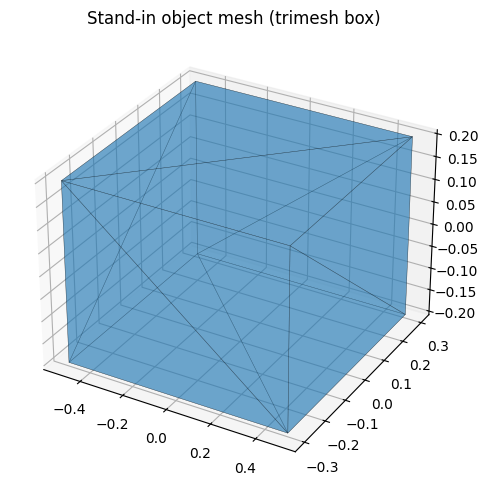

In [8]:
# Cell 3 — Verify mesh I/O with trimesh (no download required)
!pip install -q trimesh

import trimesh
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

mesh = trimesh.creation.box(extents=[1.0, 0.6, 0.4])

print(f"Vertices : {len(mesh.vertices)}")
print(f"Faces    : {len(mesh.faces)}")
print(f"Watertight: {mesh.is_watertight}")
print(f"Volume   : {mesh.volume:.4f} m³")

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
poly = Poly3DCollection(mesh.vertices[mesh.faces], alpha=0.4, edgecolor='k', linewidth=0.3)
ax.add_collection3d(poly)
ax.auto_scale_xyz(*[[mesh.bounds[0][i], mesh.bounds[1][i]] for i in range(3)])
ax.set_title("Stand-in object mesh (trimesh box)")
plt.tight_layout()
plt.show()


In [ ]:
# Cell 4 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


### Extract frames from video

In [8]:
import os

output_dir = "/content/frames"
os.makedirs(output_dir, exist_ok=True)

video_path = "/content/drive/MyDrive/hydroflaskgreen.MOV"
!ffmpeg -i "{video_path}" -vf fps=5 "{output_dir}/frame_%05d.jpg" -y -loglevel error

print(f"Extracted: {len(os.listdir(output_dir))} frames")


Extracted: 70 frames


### Frames preview

Frames: ['frame_00001.jpg', 'frame_00002.jpg', 'frame_00003.jpg'] ... frame_00014.jpg


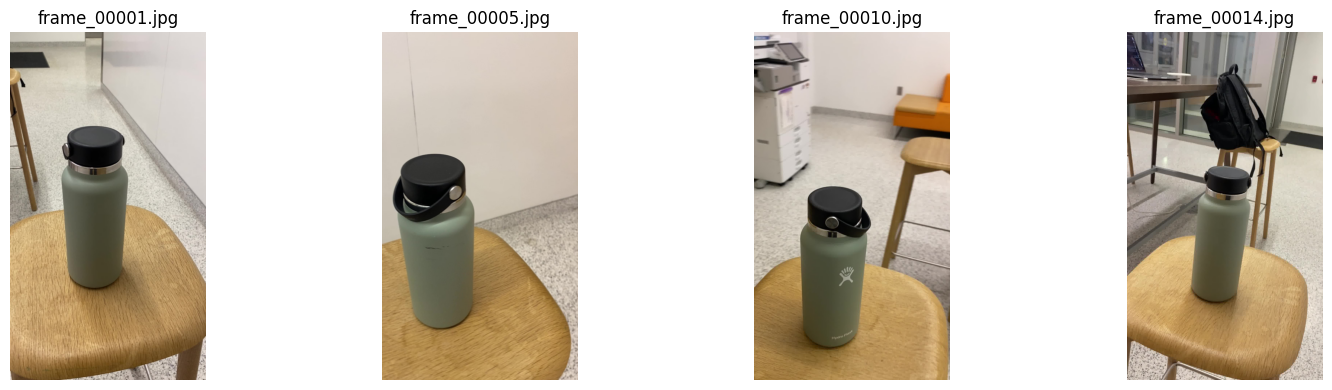

In [19]:
# Cell 6 — Preview extracted frames
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

frame_files = sorted(os.listdir("/content/frames"))
print(f"Frames: {frame_files[:3]} ... {frame_files[-1]}")

# Show 4 evenly spaced frames
indices = [0, len(frame_files)//3, 2*len(frame_files)//3, -1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i in zip(axes, indices):
    img = mpimg.imread(f"/content/frames/{frame_files[i]}")
    ax.imshow(img)
    ax.set_title(frame_files[i])
    ax.axis("off")
plt.tight_layout()
plt.show()


### COLMAP Structure from Motion pipeline
Feature extraction -> matching -> sparse reconstruction pipeline from COLMAP. 

In [9]:
import os

!apt-get install -qq colmap

# Undistort-ready output dir
os.makedirs("/content/colmap/sparse", exist_ok=True)

db_path    = "/content/colmap/database.db"
sparse_dir = "/content/colmap/sparse"

!colmap feature_extractor \
    --database_path {db_path} \
    --image_path /content/frames \
    --ImageReader.single_camera 1 \
    --SiftExtraction.use_gpu 0

!colmap exhaustive_matcher \
    --database_path {db_path} \
    --SiftMatching.use_gpu 0

!colmap mapper \
    --database_path {db_path} \
    --image_path /content/frames \
    --output_path {sparse_dir}

print("Done:", os.listdir(sparse_dir))


Extracting templates from packages: 100%
Selecting previously unselected package libdouble-conversion3:amd64.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../00-libdouble-conversion3_3.1.7-4_amd64.deb ...
Unpacking libdouble-conversion3:amd64 (3.1.7-4) ...
Selecting previously unselected package libqt5core5a:amd64.
Preparing to unpack .../01-libqt5core5a_5.15.3+dfsg-2ubuntu0.2_amd64.deb ...
Unpacking libqt5core5a:amd64 (5.15.3+dfsg-2ubuntu0.2) ...
Selecting previously unselected package libevdev2:amd64.
Preparing to unpack .../02-libevdev2_1.12.1+dfsg-1_amd64.deb ...
Unpacking libevdev2:amd64 (1.12.1+dfsg-1) ...
Selecting previously unselected package libmtdev1:amd64.
Preparing to unpack .../03-libmtdev1_1.1.6-1build4_amd64.deb ...
Unpacking libmtdev1:amd64 (1.1.6-1build4) ...
Selecting previously unselected package libgudev-1.0-0:amd64.
Preparing to unpack .../04-libgudev-1.0-0_1%3a237-2build1_amd64.deb ...
Unpacking libgudev-1.0-0:amd6

#### Final checks of reconstruction quality

### Prep files for 3d gaussian splatting
Undistort and fix the sparse folder structure

In [10]:
import os, shutil

os.makedirs("/content/colmap_undistorted", exist_ok=True)

!colmap image_undistorter \
    --image_path /content/frames \
    --input_path /content/colmap/sparse/0 \
    --output_path /content/colmap_undistorted \
    --output_type COLMAP

# Fix sparse subfolder
os.makedirs("/content/colmap_undistorted/sparse/0", exist_ok=True)
for f in ["images.bin", "cameras.bin", "points3D.bin"]:
    src = f"/content/colmap_undistorted/sparse/{f}"
    dst = f"/content/colmap_undistorted/sparse/0/{f}"
    if os.path.exists(src):
        shutil.move(src, dst)

print("Images:", len(os.listdir("/content/colmap_undistorted/images")))
print("Sparse:", os.listdir("/content/colmap_undistorted/sparse/0"))



Reading reconstruction

 => Reconstruction with 70 images and 12159 points

Image undistortion

Undistorting image [1/70]
Undistorting image [2/70]
Undistorting image [3/70]
Undistorting image [4/70]
Undistorting image [5/70]
Undistorting image [6/70]
Undistorting image [7/70]
Undistorting image [8/70]
Undistorting image [9/70]
Undistorting image [10/70]
Undistorting image [11/70]
Undistorting image [12/70]
Undistorting image [13/70]
Undistorting image [14/70]
Undistorting image [15/70]
Undistorting image [16/70]
Undistorting image [17/70]
Undistorting image [18/70]
Undistorting image [19/70]
Undistorting image [20/70]
Undistorting image [21/70]
Undistorting image [22/70]
Undistorting image [23/70]
Undistorting image [24/70]
Undistorting image [25/70]
Undistorting image [26/70]
Undistorting image [27/70]
Undistorting image [28/70]
Undistorting image [29/70]
Undistorting image [30/70]
Undistorting image [31/70]
Undistorting image [32/70]
Undistorting image [33/70]
Undistorting image [3

### Save COLMAP results to drive for future testing

In [11]:
import shutil, os

save_dir = "/content/drive/MyDrive/truerender_colmap"
if os.path.exists(save_dir):
    shutil.rmtree(save_dir)

shutil.copytree("/content/colmap_undistorted", save_dir)
print("Saved to Drive:", os.listdir(save_dir))


Saved to Drive: ['images', 'sparse', 'stereo', 'run-colmap-geometric.sh', 'run-colmap-photometric.sh']


### Install 3d gaussian splatting

In [27]:
# Cell 12 — Clone and install 3D Gaussian Splatting
import os
os.chdir("/content")

!git clone --quiet --recursive https://github.com/graphdeco-inria/gaussian-splatting
os.chdir("/content/gaussian-splatting")

!pip install -q plyfile tqdm
!pip install -q submodules/diff-gaussian-rasterization
!pip install -q submodules/simple-knn

print("Install complete")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
Install complete


### Training 3D Gaussian Splatting

##### 1.) First undistort images to PINHOLE format

In [ ]:
# Cell 13 — Undistort images to PINHOLE format
import os

os.makedirs("/content/colmap_undistorted", exist_ok=True)

!colmap image_undistorter \
    --image_path /content/frames \
    --input_path /content/colmap/sparse/0 \
    --output_path /content/colmap_undistorted \
    --output_type COLMAP

print("Done. Contents:", os.listdir("/content/colmap_undistorted"))



Reading reconstruction

 => Reconstruction with 70 images and 12130 points

Image undistortion

Undistorting image [1/70]
Undistorting image [2/70]
Undistorting image [3/70]
Undistorting image [4/70]
Undistorting image [5/70]
Undistorting image [6/70]
Undistorting image [7/70]
Undistorting image [8/70]
Undistorting image [9/70]
Undistorting image [10/70]
Undistorting image [11/70]
Undistorting image [12/70]
Undistorting image [13/70]
Undistorting image [14/70]
Undistorting image [15/70]
Undistorting image [16/70]
Undistorting image [17/70]
Undistorting image [18/70]
Undistorting image [19/70]
Undistorting image [20/70]
Undistorting image [21/70]
Undistorting image [22/70]
Undistorting image [23/70]
Undistorting image [24/70]
Undistorting image [25/70]
Undistorting image [26/70]
Undistorting image [27/70]
Undistorting image [28/70]
Undistorting image [29/70]
Undistorting image [30/70]
Undistorting image [31/70]
Undistorting image [32/70]
Undistorting image [33/70]
Undistorting image [3

### Rename files and install SAM3

In [13]:
import os, sys, shutil

# Rename frames for SAM 3 (needs integer filenames)
sam_dir = "/content/sam2_frames"
os.makedirs(sam_dir, exist_ok=True)
frames = sorted(os.listdir("/content/colmap_undistorted/images"))
for i, fname in enumerate(frames):
    shutil.copy(f"/content/colmap_undistorted/images/{fname}", f"{sam_dir}/{i}.jpg")
print(f"Renamed {len(frames)} frames")

# Install SAM 3
os.chdir("/content")
!git clone --quiet https://github.com/facebookresearch/sam3.git
os.chdir("/content/sam3")
!pip install -q -e .
print("SAM 3 installed")


Renamed 70 frames
fatal: destination path 'sam3' already exists and is not an empty directory.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
SAM 3 installed


#### Load mounted data and restore COLMAP and run SAM3 Segmentation 

In [4]:
import sys, os, cv2, shutil
import numpy as np
from google.colab import drive

# Mount Drive and restore COLMAP
drive.mount('/content/drive')
shutil.copytree("/content/drive/MyDrive/truerender_colmap", "/content/colmap_undistorted", dirs_exist_ok=True)
print(f"Restored {len(os.listdir('/content/colmap_undistorted/images'))} images")

# Rename frames for SAM 3
sam_dir = "/content/sam2_frames"
os.makedirs(sam_dir, exist_ok=True)
orig_frames = sorted(os.listdir("/content/colmap_undistorted/images"))
for i, fname in enumerate(orig_frames):
    shutil.copy(f"/content/colmap_undistorted/images/{fname}", f"{sam_dir}/{i}.jpg")
print(f"Renamed {len(orig_frames)} frames")

# Run SAM 3
from sam3.model_builder import build_sam3_video_predictor
predictor = build_sam3_video_predictor()

response = predictor.handle_request(dict(type="start_session", resource_path="/content/sam2_frames"))
session_id = response["session_id"]

predictor.handle_request(dict(type="add_prompt", session_id=session_id, frame_index=0, text="green hydroflask water bottle"))
print("Prompt added — propagating...")

masked_dir = "/content/frames_masked_sam3"
os.makedirs(masked_dir, exist_ok=True)

for result in predictor.propagate_in_video(session_id):
    frame_idx = result["frame_index"]
    mask = result["outputs"]["out_binary_masks"][0]
    img = cv2.imread(f"/content/colmap_undistorted/images/{orig_frames[frame_idx]}")
    img[~mask] = 255
    cv2.imwrite(f"{masked_dir}/{orig_frames[frame_idx]}", img)

predictor.close_session(session_id)
print(f"Saved {len(os.listdir(masked_dir))} masked frames")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Restored 70 images


INFO 2026-04-16 05:09:45,914 15497 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-04-16 05:09:45,915 15497 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-04-16 05:09:45,915 15497 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...


Renamed 70 frames


INFO 2026-04-16 05:09:53,599 15497 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-04-16 05:09:57,391 15497 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-04-16 05:09:57,392 15497 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***


frame loading (image folder) [rank=0]: 100%|██████████| 70/70 [00:03<00:00, 21.48it/s]
INFO 2026-04-16 05:10:00,790 15497 sam3_base_predictor.py: 130: started new session 1cfb6b3a-adb7-4f8f-b424-794994c46af3


Prompt added — propagating...


propagate_in_video:   0%|          | 0/70 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-04-16 05:10:24,642 15497 sam3_base_predictor.py: 286: propagation ended in session 1cfb6b3a-adb7-4f8f-b424-794994c46af3
INFO 2026-04-16 05:10:24,886 15497 sam3_base_predictor.py: 305: removed session 1cfb6b3a-adb7-4f8f-b424-794994c46af3


Saved 70 masked frames


### Preview masked frames

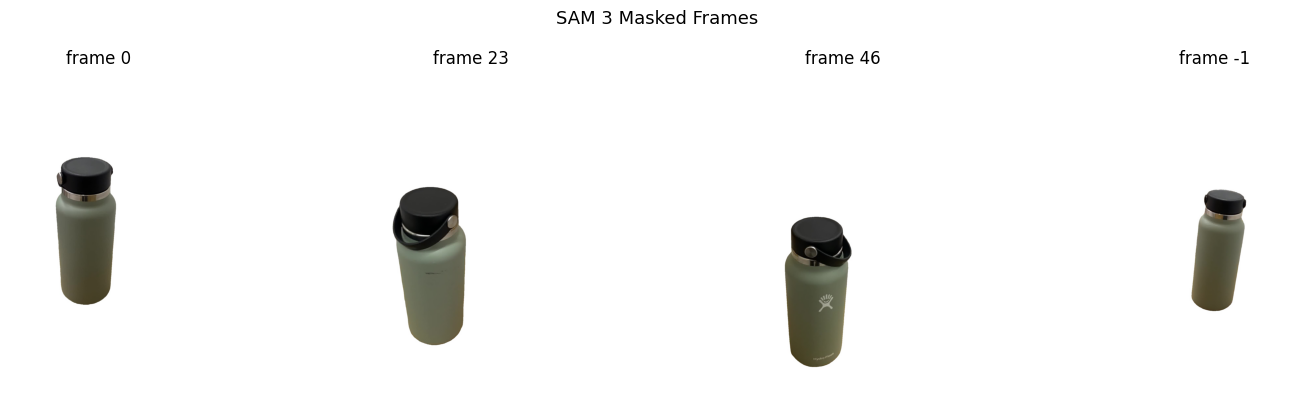

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

masked_dir = "/content/frames_masked_sam3"
frames = sorted(os.listdir(masked_dir))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
indices = [0, len(frames)//3, 2*len(frames)//3, -1]
for ax, i in zip(axes, indices):
    img = mpimg.imread(f"{masked_dir}/{frames[i]}")
    ax.imshow(img)
    ax.set_title(f"frame {i}")
    ax.axis("off")
plt.suptitle("SAM 3 Masked Frames", fontsize=13)
plt.tight_layout()
plt.show()


### Save masked frames

In [6]:
import shutil, os

save_dir = "/content/drive/MyDrive/truerender_masked_frames"
if os.path.exists(save_dir):
    shutil.rmtree(save_dir)
shutil.copytree("/content/frames_masked_sam3", save_dir)
print(f"Saved {len(os.listdir(save_dir))} frames to Drive")


Saved 70 frames to Drive


### Install 3D Gaussian splatting and Train

In [7]:
import os
os.chdir("/content")
!git clone --quiet --recursive https://github.com/graphdeco-inria/gaussian-splatting
os.chdir("/content/gaussian-splatting")
!pip install -q plyfile tqdm
!pip install -q submodules/diff-gaussian-rasterization
!pip install -q submodules/simple-knn
print("Installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
Installed


Replace images with masked versions and retrain

In [8]:
import os, shutil

# Replace images with masked versions
for f in os.listdir("/content/frames_masked_sam3"):
    shutil.copy(f"/content/frames_masked_sam3/{f}",
                f"/content/colmap_undistorted/images/{f}")
print("Images replaced")

# Train 3DGS on masked frames
os.chdir("/content/gaussian-splatting")
!python train.py \
    -s /content/colmap_undistorted \
    -m /content/gs_output_masked \
    --iterations 7000 \
    --save_iterations 7000


Images replaced
2026-04-16 05:21:40.684862: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 05:21:40.704007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776316900.727153   19424 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776316900.734767   19424 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776316900.754818   19424 computation_placer.cc:177] computation placer already registered. Please check linkage an

### Results from Training
PSNR 35.6 dB - excellent >30dB great ratio
L1 = 0.002104382 


In [9]:
import shutil, os

save_dir = "/content/drive/MyDrive/truerender_gs_output_masked"
if os.path.exists(save_dir):
    shutil.rmtree(save_dir)
shutil.copytree("/content/gs_output_masked", save_dir)
print(f"Saved to Drive: {os.listdir(save_dir)}")


Saved to Drive: ['cameras.json', 'exposure.json', 'events.out.tfevents.1776316905.c1744b823932.19424.0', 'cfg_args', 'point_cloud', 'input.ply']
